In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/MyDrive/praktikum_ml/praktikum06/"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.svm import SVC

In [4]:
df = pd.read_csv(path + "data/data.csv", sep=",")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [11]:
X = df[['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']]
y = df['diagnosis']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

SVC(kernel='linear')

In [14]:
y_pred = model.predict(X_test)

In [15]:
print(f"Akkurasi:{accuracy_score(y_test, y_pred) * 100:.2f}%")

print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))

Akkurasi:93.86%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           B       0.96      0.94      0.95        71
           M       0.91      0.93      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114




Confusion Matrix:
 [[67  4]
 [ 3 40]]


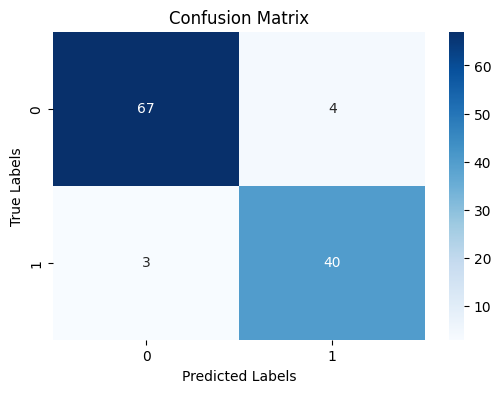

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("\nConfusion Matrix:\n", confusion_matrix(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

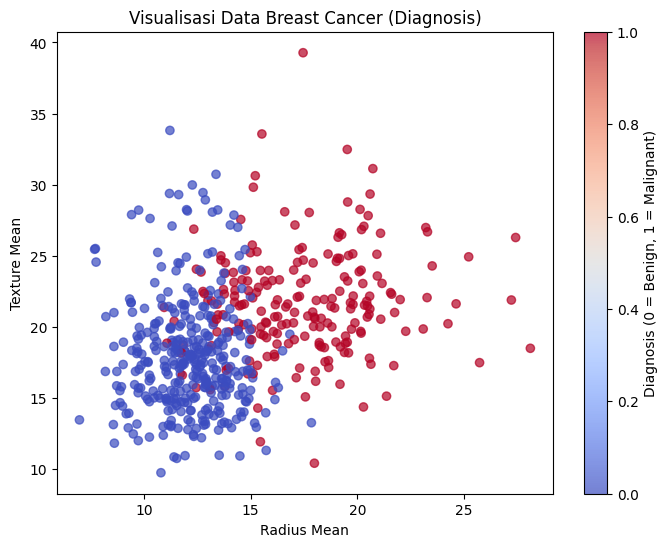

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    df['radius_mean'],
    df['texture_mean'],
    c=df['diagnosis'].astype('category').cat.codes,
    cmap='coolwarm',
    alpha=0.7
)
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.title('Visualisasi Data Breast Cancer (Diagnosis)')
plt.colorbar(label='Diagnosis (0 = Benign, 1 = Malignant)')
plt.show()



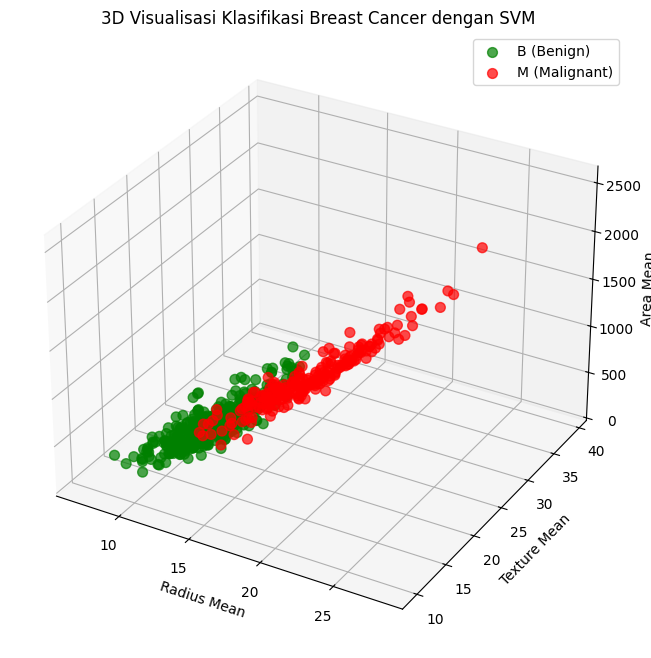

In [25]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

le = LabelEncoder()
df['DiagnosisEncoded'] = le.fit_transform(df['diagnosis'])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['g', 'r']
labels = le.classes_

for i, diagnosis in enumerate(labels):
    subset = df[df['DiagnosisEncoded'] == i]
    ax.scatter(
        subset['radius_mean'],
        subset['texture_mean'],
        subset['area_mean'],
        color=colors[i],
        label=f"{diagnosis} ({'Benign' if diagnosis=='B' else 'Malignant'})",
        s=50,
        alpha=0.7
    )

ax.set_xlabel('Radius Mean')
ax.set_ylabel('Texture Mean')
ax.set_zlabel('Area Mean')
ax.set_title('3D Visualisasi Klasifikasi Breast Cancer dengan SVM')
ax.legend()
plt.show()
